In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, pearsonr, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# style plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# load dataset
df = pd.read_csv('AI_impact_Student_Life_2026.csv')

print("=" * 60)
print("Dataset overview")
print("=" * 60)

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f" {col}")

print(f"\nFirst 5 rows:")
df.head()

Dataset overview

Shape: 1500 rows, 11 columns

Column names:
 Student_ID
 Age
 Major
 Primary_AI_Tool
 Task_Frequency_Daily
 Main_Usage_Case
 GPA_Baseline
 GPA_Post_AI
 Time_Saved_Hours_Weekly
 AI_Ethics_Concern
 Career_Confidence_Score

First 5 rows:


,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [7]:
# calculate GPA change
df['GPA_Change'] = df['GPA_Post_AI'] - df['GPA_Baseline']
df['GPA_Change_Percent'] = (df['GPA_Change'] / df['GPA_Baseline']) * 100
df['GPA_Improved'] = (df['GPA_Change'] > 0).astype(int)

In [8]:
# create time saved categories
def time_category(hours):
    if hours <= 5:
        return 'Low (0-5 hrs)'
    elif hours <= 10:
        return 'Medium (6-10 hrs)'
    else:
        return 'High (11+ hrs)'

df['Time_Saved_Category'] = df['Time_Saved_Hours_Weekly'].apply(time_category)

In [9]:
# create GPA impact category
def gpa_category(change):
    if change > 0.05:
        return 'Significant Increase'
    elif change > 0:
        return 'Slight Increase'
    elif change == 0:
        return 'No Change'
    elif change > -0.05:
        return 'Slight Decrease'
    else:
        return 'Significant Decrease'

df['GPA_Impact_Category'] = df['GPA_Change'].apply(gpa_category)

print("New columns created:")
print(f"GPA_Change: {df['GPA_Change'].mean():.3f} (average change)")
print(f"GPA_Improved: {df['GPA_Improved'].sum()} students ({df['GPA_Improved'].mean()*100:.1f}%)")
print(f"Time_Saved_Category: {df['Time_Saved_Category'].value_counts().to_dict()}")
print(f"\nUpdated dataset info:")
df.info()

New columns created:
GPA_Change: 0.088 (average change)
GPA_Improved: 894 students (59.6%)
Time_Saved_Category: {'High (11+ hrs)': 547, 'Medium (6-10 hrs)': 519, 'Low (0-5 hrs)': 434}

Updated dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non

In [10]:
# statistical analysis
print("=" * 60)
print("Numerical values summary")
print("=" *60)

numerical_cols = ['Age', 'Task_Frequency_Daily', 'GPA_Baseline', 'GPA_Post_AI',
                  'Time_Saved_Hours_Weekly', 'Career_Confidence_Score', 'GPA_Change']

df[numerical_cols].describe().round(2)

Numerical values summary


,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score,GPA_Change
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,21.49,5.41,3.26,3.34,8.51,5.42,0.09
std,2.30,2.91,0.43,0.44,4.07,2.84,0.13
min,18.00,1.00,2.50,2.40,2.00,1.00,-0.10
25%,20.00,3.00,2.88,2.98,5.00,3.00,0.00
50%,21.00,5.00,3.26,3.36,9.00,5.00,0.10
75%,23.00,8.00,3.62,3.71,12.00,8.00,0.20
max,25.00,10.00,4.00,4.00,15.00,10.00,0.30


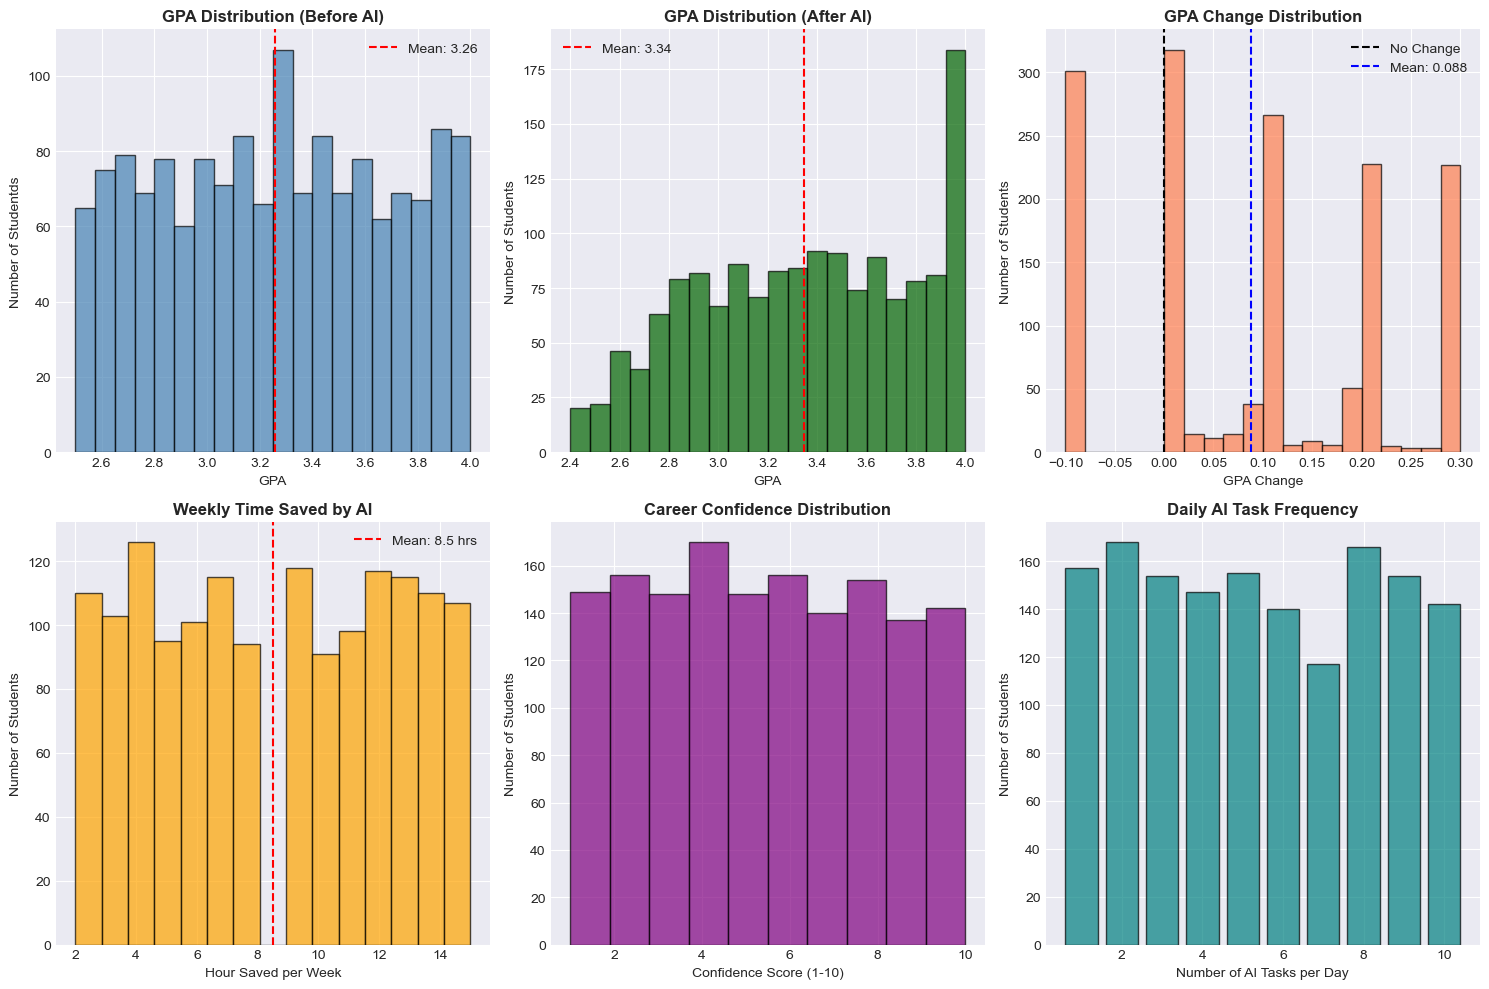

Chart saved: distribution_plots.png


In [19]:
# Distribution visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# GPA Baseline
axes[0, 0].hist(df['GPA_Baseline'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('GPA Distribution (Before AI)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('GPA')
axes[0, 0].set_ylabel('Number of Studentds')
axes[0, 0].axvline(df['GPA_Baseline'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df['GPA_Baseline'].mean():.2f}')
axes[0, 0].legend()

# GPA Post AI
axes[0, 1].hist(df['GPA_Post_AI'], bins=20, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0, 1].set_title('GPA Distribution (After AI)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('GPA')
axes[0, 1].set_ylabel('Number of Students')
axes[0, 1].axvline(df['GPA_Post_AI'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df['GPA_Post_AI'].mean():.2f}')
axes[0, 1].legend()

# GPA Change
axes[0, 2].hist(df['GPA_Change'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 2].set_title('GPA Change Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('GPA Change')
axes[0, 2].set_ylabel('Number of Students')
axes[0, 2].axvline(0, color='black', linestyle='--', label='No Change')
axes[0, 2].axvline(df['GPA_Change'].mean(), color='blue', linestyle='--',
                   label=f'Mean: {df['GPA_Change'].mean():.3f}')
axes[0, 2].legend()

# Time that is saved
axes[1, 0].hist(df['Time_Saved_Hours_Weekly'], bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Weekly Time Saved by AI', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour Saved per Week')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].axvline(df['Time_Saved_Hours_Weekly'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df['Time_Saved_Hours_Weekly'].mean():.1f} hrs')
axes[1, 0].legend()

# Career Confidence Distribution
axes[1, 1].hist(df['Career_Confidence_Score'], bins=10, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('Career Confidence Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Confidence Score (1-10)')
axes[1, 1].set_ylabel('Number of Students')

# Frequency Task
freq_counts = df['Task_Frequency_Daily'].value_counts().sort_index()
axes[1, 2].bar(freq_counts.index, freq_counts.values, edgecolor='black', alpha=0.7, color='teal')
axes[1, 2].set_title('Daily AI Task Frequency', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Number of AI Tasks per Day')
axes[1, 2].set_ylabel('Number of Students')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: distribution_plots.png")

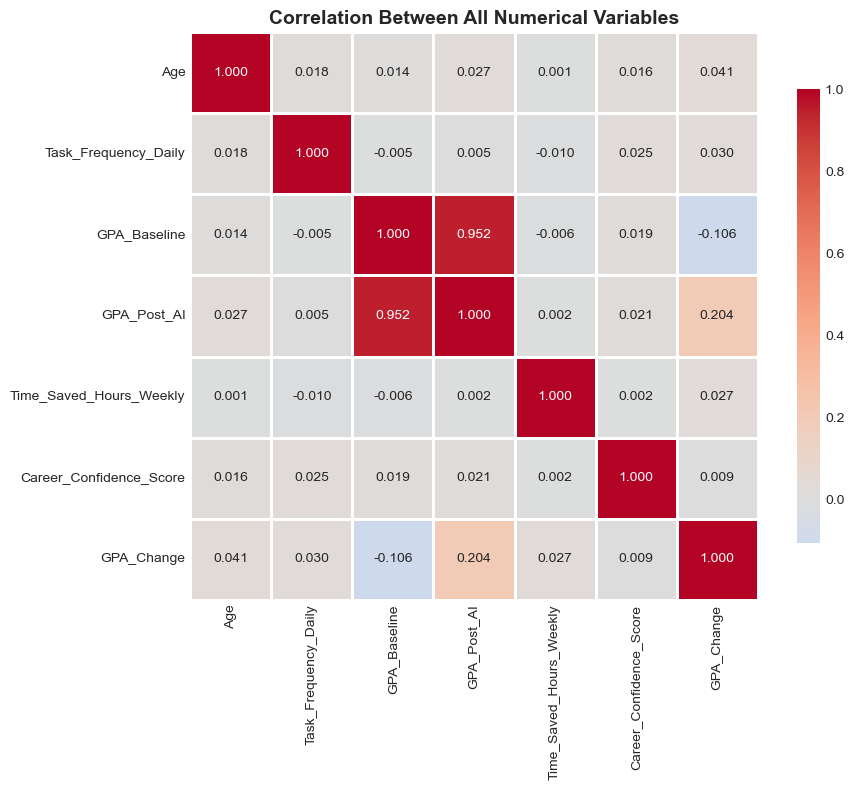


Key Correlations:
GPA_Baseline .. GPA_Post_AI: 0.952
GPA_Baseline .. GPA_Change: -0.106
GPA_Post_AI .. GPA_Change: 0.204


In [20]:
# Correlation analysis
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Between All Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey Correlations:')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.1:
            print(f"{corr_matrix.columns[i]} .. {corr_matrix.columns[j]}: {corr_val:.3f}")

In [22]:
# Performance comparison
major_stats = df.groupby('Major').agg({
    'GPA_Change': 'mean',
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean',
    'Task_Frequency_Daily': 'mean',
    'Student_ID': 'count'
}).round(3)

major_stats.columns = ['Avg_GPA_Change', 'Avg_Time_Saved', 'Avg_Career_Confidence', 'Avg_Task_Frequency', 'Student_Count']
major_stats = major_stats.sort_values('Avg_GPA_Change', ascending=False)

print("Performance by Major:")
major_stats

Performance by Major:


,Avg_GPA_Change,Avg_Time_Saved,Avg_Career_Confidence,Avg_Task_Frequency,Student_Count
Major,,,,,
Software Engineering,0.102,8.446,5.289,5.669,242
Biology,0.093,8.452,5.139,5.201,259
Business Administration,0.091,8.750,5.680,5.547,256
Data Science,0.084,8.730,5.668,5.336,259
Modern History,0.081,8.480,5.050,5.548,221
Fine Arts,0.075,8.202,5.616,5.186,263


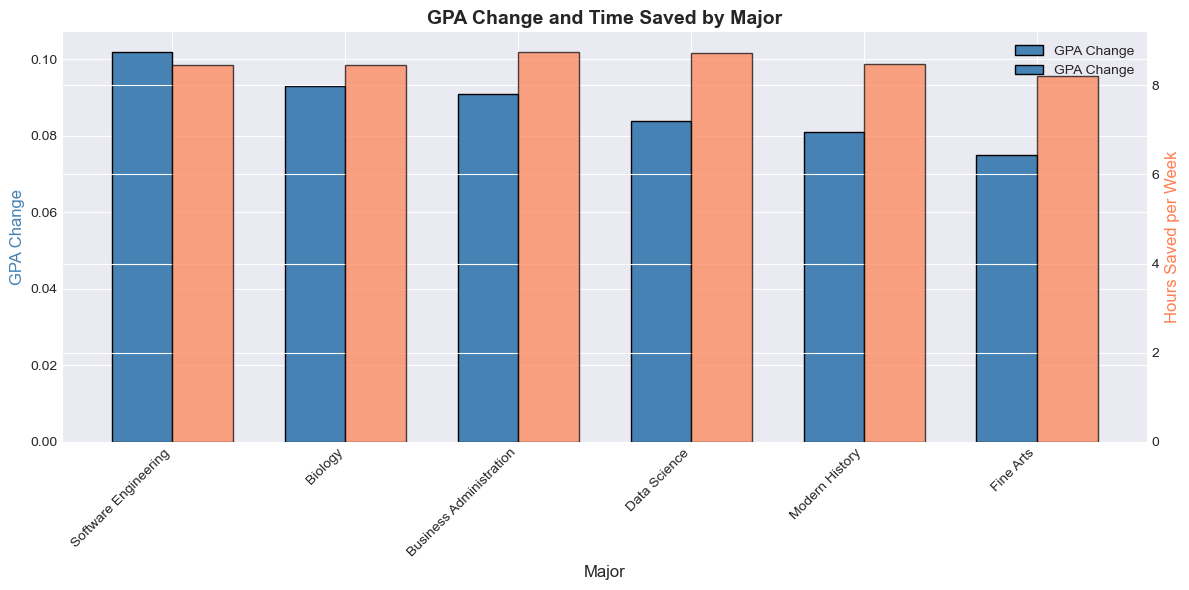

Chart saved: major_analysis.png


In [30]:
# Major Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(major_stats))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], major_stats['Avg_GPA_Change'], width, label='GPA Change', color='steelblue', edgecolor='black')

ax2 = ax.twinx()
bars2 = ax2.bar([i + width/2 for i in x], major_stats['Avg_Time_Saved'], width, label='Time Saved (hrs/week)', color='coral',
                edgecolor='black', alpha=0.7)

ax.set_xlabel('Major', fontsize=12)
ax.set_ylabel('GPA Change', fontsize=12, color='steelblue')
ax2.set_ylabel('Hours Saved per Week', fontsize=12, color='coral')
ax.set_title('GPA Change and Time Saved by Major', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(major_stats.index, rotation=45, ha='right')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('major_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: major_analysis.png")

In [32]:
# Compare AI tools
tool_stats = df.groupby('Primary_AI_Tool').agg({
    'GPA_Change': ['mean', 'std', 'count'],
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean'
}).round(3)

tool_stats.columns = ['GPA_Change_Mean', 'GPA_Change_Std', 'Count', 'Time_Saved_Mean', 'Career_Confidence_Mean']
tool_stats = tool_stats.sort_values('GPA_Change_Mean', ascending=False)

print("AI Tool Performance Ranking:")
tool_stats

AI Tool Performance Ranking:


,GPA_Change_Mean,GPA_Change_Std,Count,Time_Saved_Mean,Career_Confidence_Mean
Primary_AI_Tool,,,,,
ChatGPT-4o,0.094,0.135,288,8.330,5.354
Perplexity,0.092,0.134,302,8.848,5.699
GitHub Copilot,0.091,0.139,311,8.441,5.344
Gemini Pro,0.082,0.137,302,8.642,5.166
Claude 3.5,0.080,0.129,297,8.279,5.525


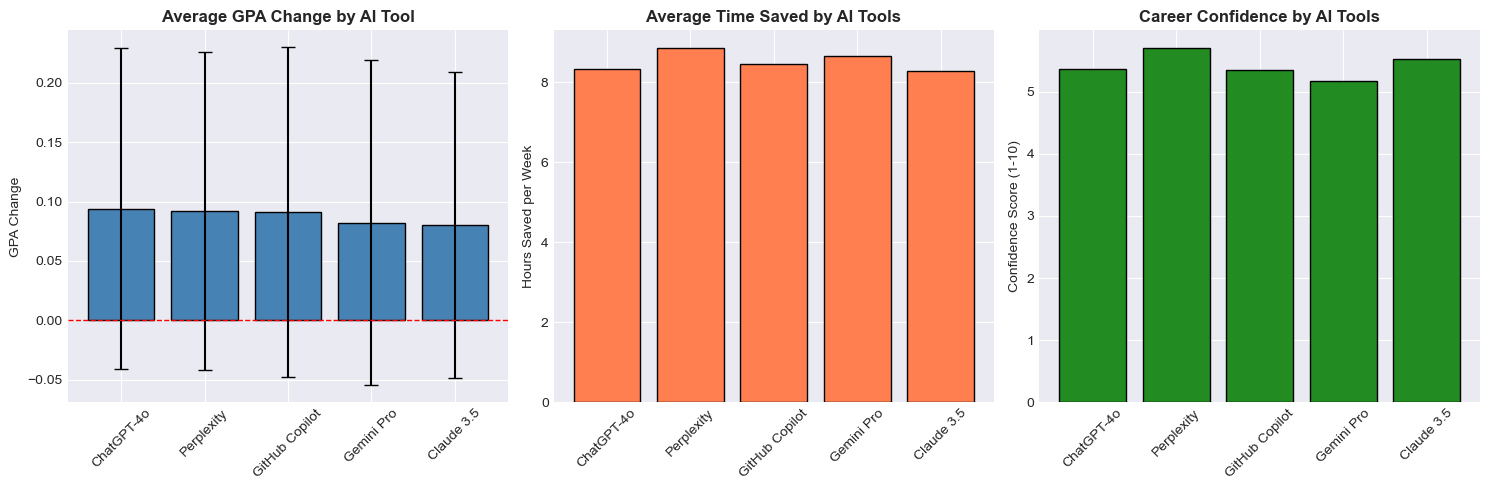

Chart saved: ai_tool_comparison.png


In [34]:
# AI tool visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tools = tool_stats.index

# GPA Change
axes[0].bar(tools, tool_stats['GPA_Change_Mean'], yerr=tool_stats['GPA_Change_Std'],
            capsize=5, color='steelblue', edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Average GPA Change by AI Tool', fontsize=12, fontweight='bold')
axes[0].set_ylabel('GPA Change')
axes[0].tick_params(axis='x', rotation=45)

# Time Saved
axes[1].bar(tools, tool_stats['Time_Saved_Mean'], color='coral', edgecolor='black')
axes[1].set_title('Average Time Saved by AI Tools', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Hours Saved per Week')
axes[1].tick_params(axis='x', rotation=45)

# Career Confidence
axes[2].bar(tools, tool_stats['Career_Confidence_Mean'], color='forestgreen', edgecolor='black')
axes[2].set_title('Career Confidence by AI Tools', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Confidence Score (1-10)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('ai_tool_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: ai_tool_comparison.png")

In [35]:
# Analyze cases
usage_stats = df.groupby('Main_Usage_Case').agg({
    'GPA_Change': 'mean',
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean',
    'Student_ID': 'count'
}).round(3)

usage_stats.columns = ['Avg_GPA_Change', 'Avg_Time_Saved', 'Avg_Career_Confidence', 'Count']
usage_stats = usage_stats.sort_values('Avg_GPA_Change', ascending=False)

print("Performance by Usage Case:")
usage_stats

Performance by Usage Case:


,Avg_GPA_Change,Avg_Time_Saved,Avg_Career_Confidence,Count
Main_Usage_Case,,,,
Code Debugging,0.095,8.288,5.481,264
Brainstorming,0.088,8.622,5.259,286
Essay Drafting,0.088,8.761,5.365,301
Literature Review,0.087,8.422,5.338,308
Exam Prep,0.083,8.446,5.619,341


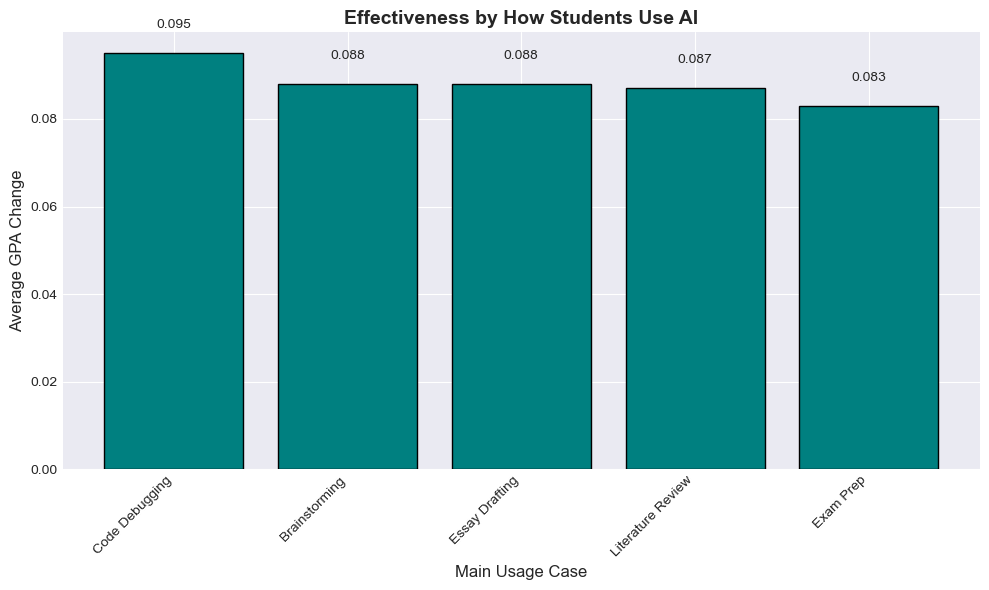

Chart saved: usage_case_analysis.png


In [36]:
# Usage case effectiveness
fig, ax = plt.subplots(figsize=(10, 6))
usage_cases = usage_stats.index
x = range(len(usage_cases))

bars = ax.bar(x, usage_stats['Avg_GPA_Change'], color='teal', edgecolor='black')
ax.set_xlabel('Main Usage Case', fontsize=12)
ax.set_ylabel('Average GPA Change', fontsize=12)
ax.set_title('Effectiveness by How Students Use AI', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(usage_cases, rotation=45, ha='right')

# value labels
for i, (bar, val) in enumerate(zip(bars, usage_stats['Avg_GPA_Change'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('usage_case_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: usage_case_analysis.png")

In [44]:
# statistical significance tests
print("=" * 60)
print("Statistical Significance Tests")
print("=" * 60)

# Paired T-Test
print("\n1️Paired T-Test: GPA Before vs After AI")
t_stat, p_value = stats.ttest_rel(df['GPA_Baseline'], df['GPA_Post_AI'])
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("RESULT: Statistically significant! AI improved GPA overall.")
else:
    print("RESULT: Not statistically significant.")

Statistical Significance Tests

1️Paired T-Test: GPA Before vs After AI
T-statistic: -25.2037
P-value: 0.000000
RESULT: Statistically significant! AI improved GPA overall.


In [45]:
# Test 2: ANOVA by Major
print("\nANOVA Test: GPA Change Across Different Majors")
major_groups = [group['GPA_Change'].values for name, group in df.groupby('Major')]
f_stat, p_value = f_oneway(*major_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("RESULT: Significant differences in AI benefit across majors.")
else:
    print("RESULT: No significant differences across majors.")


ANOVA Test: GPA Change Across Different Majors
F-statistic: 1.2968
P-value: 0.262573
RESULT: No significant differences across majors.


In [46]:
# Correlation
print("\nPearson Correlation: Time Saved vs GPA Change")
corr, p_value = pearsonr(df['Time_Saved_Hours_Weekly'], df['GPA_Change'])
print(f"   Correlation coefficient: {corr:.4f}")
print(f"   P-value: {p_value:.6f}")
if p_value < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"RESULT: Significant {direction} correlation ({corr:.3f})")
else:
    print("RESULT: No significant correlation.")


Pearson Correlation: Time Saved vs GPA Change
   Correlation coefficient: 0.0274
   P-value: 0.289791
RESULT: No significant correlation.


In [47]:
# Ethics Concern Impact
print("\nT-Test: High Ethics Concern vs Low Ethics Concern")
high_ethics = df[df['AI_Ethics_Concern'] == 'High']['GPA_Change']
low_ethics = df[df['AI_Ethics_Concern'] == 'Low']['GPA_Change']
t_stat, p_value = ttest_ind(high_ethics, low_ethics)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("RESULT: Ethics concerns significantly affect GPA outcomes.")
else:
    print("RESULT: No significant difference based on ethics concerns.")


T-Test: High Ethics Concern vs Low Ethics Concern
T-statistic: 1.3219
P-value: 0.186488
RESULT: No significant difference based on ethics concerns.


In [51]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ['Major', 'Primary_AI_Tool', 'Main_Usage_Case', 'AI_Ethics_Concern']

df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[f'{col}_encoded'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

In [52]:
# Prepare features
feature_cols = ['Age', 'Task_Frequency_Daily', 'Time_Saved_Hours_Weekly', 
                'Major_encoded', 'Primary_AI_Tool_encoded', 
                'Main_Usage_Case_encoded', 'AI_Ethics_Concern_encoded']

X = df_encoded[feature_cols]
y = df['GPA_Change']

In [53]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1200
Testing samples: 300


In [57]:
# Linear Regression
print("\nLinear Regression Model:")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"R² Score: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")


Linear Regression Model:
R² Score: -0.0134
RMSE: 0.1378


In [58]:
# Random Forest
print("\nRandom Forest Regressor:")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")


Random Forest Regressor:
R² Score: -0.0906
RMSE: 0.1429


In [59]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nMost Important Factors for GPA Change:")
feature_importance


Most Important Factors for GPA Change:


,Feature,Importance
2,Time_Saved_Hours_Weekly,0.210143
1,Task_Frequency_Daily,0.172203
0,Age,0.162339
3,Major_encoded,0.135774
5,Main_Usage_Case_encoded,0.125776
4,Primary_AI_Tool_encoded,0.122358
6,AI_Ethics_Concern_encoded,0.071408


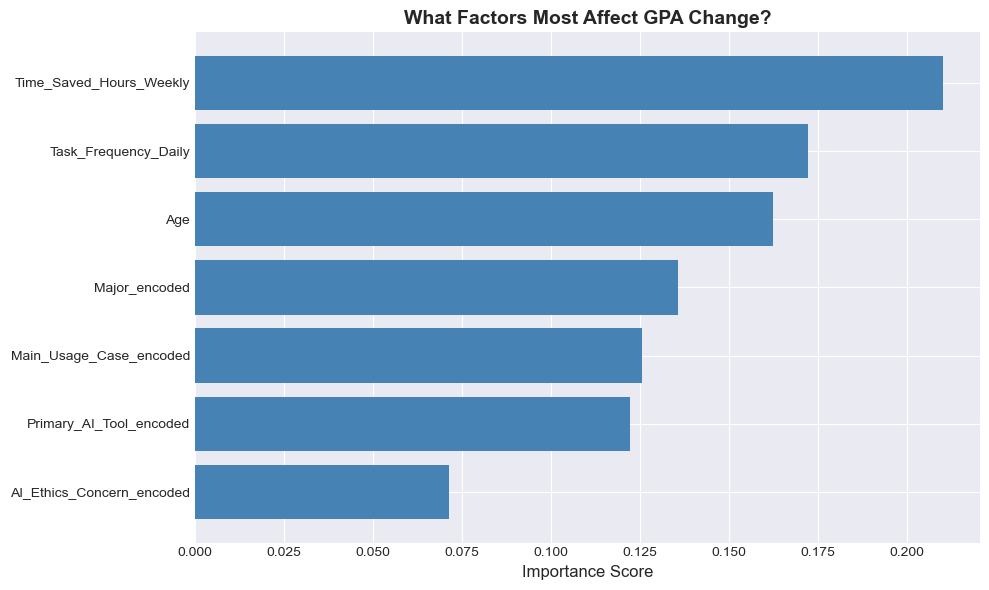

Chart saved: feature_importance.png


In [60]:
# feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('What Factors Most Affect GPA Change?', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: feature_importance.png")

In [61]:
X_class = df_encoded[feature_cols]
y_class = df['GPA_Improved']

In [62]:
# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [63]:
# Scale
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

In [64]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c_scaled, y_train_c)
y_pred_c = rf_clf.predict(X_test_c_scaled)

In [65]:
# Results
accuracy = accuracy_score(y_test_c, y_pred_c)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nDetailed Performance:")
print(classification_report(y_test_c, y_pred_c, target_names=['No Improvement', 'Improved']))

Model Accuracy: 0.5467 (54.7%)

Detailed Performance:
                precision    recall  f1-score   support

No Improvement       0.40      0.26      0.31       121
      Improved       0.60      0.74      0.66       179

      accuracy                           0.55       300
     macro avg       0.50      0.50      0.49       300
  weighted avg       0.52      0.55      0.52       300



In [71]:
# Features clustering
cluster_features = ['GPA_Change', 'Time_Saved_Hours_Weekly', 'Career_Confidence_Score', 'Task_Frequency_Daily']
X_cluster = df[cluster_features]

In [72]:
# Scale
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [73]:
# K-Means clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [74]:
# Analyze clusters
cluster_analysis = df.groupby('Cluster').agg({
    'GPA_Change': 'mean',
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean',
    'Task_Frequency_Daily': 'mean',
    'Student_ID': 'count'
}).round(3)

cluster_analysis.columns = ['Avg_GPA_Change', 'Avg_Time_Saved', 'Avg_Career_Confidence', 'Avg_Task_Frequency', 'Count']

In [75]:
# Name clusters
cluster_names = {
    0: 'Balanced Users',
    1: 'Power Users (High Impact)',
    2: 'Career Focused',
    3: 'Casual Users'
}

df['Segment'] = df['Cluster'].map(cluster_names)

print("Student Segments Found:")
cluster_analysis

Student Segments Found:


,Avg_GPA_Change,Avg_Time_Saved,Avg_Career_Confidence,Avg_Task_Frequency,Count
Cluster,,,,,
0,0.114,11.869,5.275,2.763,397
1,0.096,11.807,5.914,8.302,348
2,0.101,4.871,8.137,5.398,357
3,0.043,5.540,2.686,5.523,398


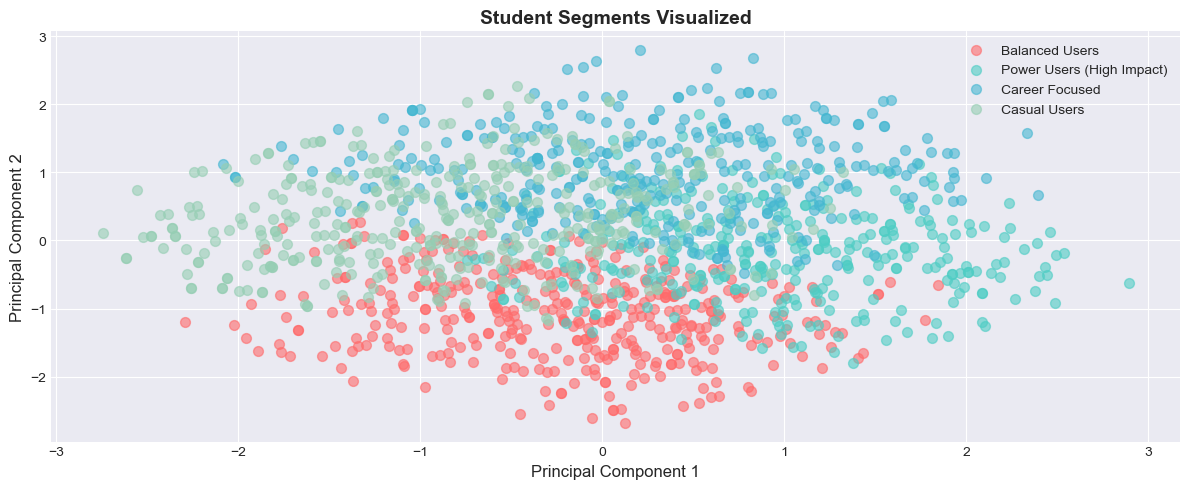

Chart saved: student_segments.png

Segment Distribution:
Segment
Casual Users                 398
Balanced Users               397
Career Focused               357
Power Users (High Impact)    348
Name: count, dtype: int64


In [76]:
# student segments
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(12, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], 
                label=cluster_names[i], alpha=0.6, s=50)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Student Segments Visualized', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('student_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: student_segments.png")

print("\nSegment Distribution:")
print(df['Segment'].value_counts())

In [77]:
# Analyze impact ethics concerns
ethics_summary = df.groupby('AI_Ethics_Concern').agg({
    'GPA_Change': 'mean',
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean',
    'GPA_Improved': 'mean',
    'Student_ID': 'count'
}).round(3)

ethics_summary.columns = ['Avg_GPA_Change', 'Avg_Time_Saved', 'Avg_Career_Confidence', 'Improvement_Rate', 'Count']
ethics_summary['Improvement_Rate'] = ethics_summary['Improvement_Rate'] * 100

print("Impact of Ethics Concerns:")
ethics_summary

Impact of Ethics Concerns:


,Avg_GPA_Change,Avg_Time_Saved,Avg_Career_Confidence,Improvement_Rate,Count
AI_Ethics_Concern,,,,,
High,0.089,8.454,5.476,59.5,496
Low,0.078,8.461,5.402,55.3,523
Medium,0.098,8.622,5.374,64.4,481


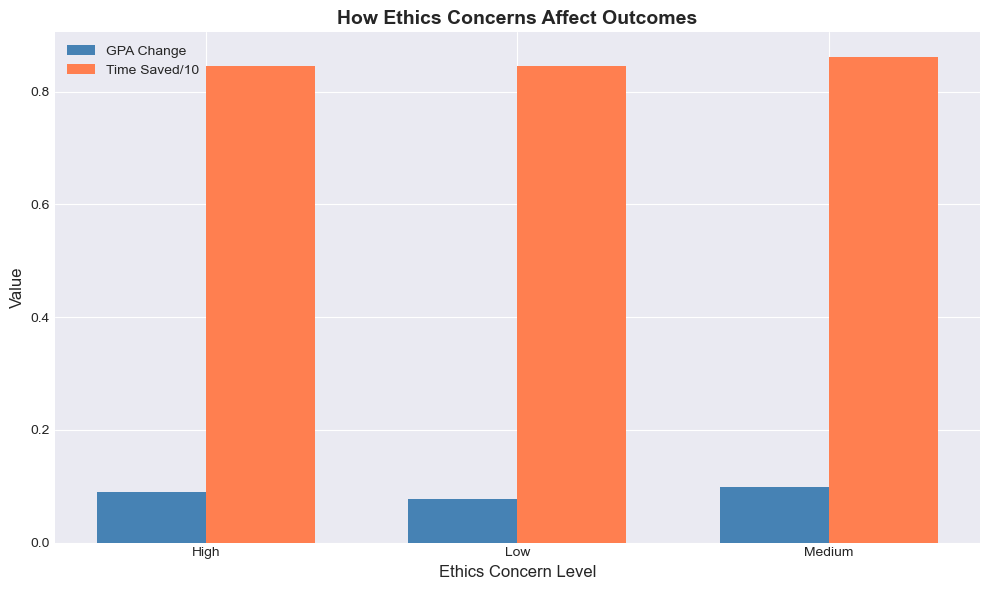

Chart saved: ethics_analysis.png


In [78]:
# ethics impact
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(ethics_summary))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], ethics_summary['Avg_GPA_Change'], width, 
               label='GPA Change', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], ethics_summary['Avg_Time_Saved']/10, width, 
               label='Time Saved/10', color='coral')

ax.set_xlabel('Ethics Concern Level', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('How Ethics Concerns Affect Outcomes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ethics_summary.index)
ax.legend()

plt.tight_layout()
plt.savefig('ethics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: ethics_analysis.png")

In [89]:
# final summary
total_students = len(df)
improved_count = df['GPA_Improved'].sum()
improvement_rate = (improved_count / total_students) * 100
avg_time_saved = df['Time_Saved_Hours_Weekly'].mean()
avg_gpa_change = df['GPA_Change'].mean()
best_tool = tool_stats.index[0]
best_major = major_stats.index[0]
best_usage = usage_stats.index[0]

print(f"""
Total Students Analyzed: {total_students}
GPA Improvement:
{improvement_rate:.1f}% of students improved their GPA
Average GPA change: +{avg_gpa_change:.3f} points
Time Savings:
Average time saved: {avg_time_saved:.1f} hours per week
This is equivalent to {avg_time_saved/40*100:.0f}% of a full work week!

Best Performers:
Best AI Tool: {best_tool}
Best Major: {best_major}
Best Usage: {best_usage}
""")

print("\nRecommendations:")
print("For Students:")
print("Use AI for code debugging and essay drafting")
print("Aim for 5-10 AI tasks per week")
print("Balance AI assistance with personal learning")
print("\nFor Educators:")
print("Integrate AI literacy into curriculum")
print("Provide guidelines for ethical AI use")
print("Share best practices from high-performing students")


Total Students Analyzed: 1500
GPA Improvement:
59.6% of students improved their GPA
Average GPA change: +0.088 points
Time Savings:
Average time saved: 8.5 hours per week
This is equivalent to 21% of a full work week!

Best Performers:
Best AI Tool: ChatGPT-4o
Best Major: Software Engineering
Best Usage: Code Debugging


Recommendations:
For Students:
Use AI for code debugging and essay drafting
Aim for 5-10 AI tasks per week
Balance AI assistance with personal learning

For Educators:
Integrate AI literacy into curriculum
Provide guidelines for ethical AI use
Share best practices from high-performing students


In [90]:
# Export results to files
# Save processed data
df.to_csv('AI_Impact_Processed.csv', index=False)
print("Saved: AI_Impact_Processed.csv")

# Save analysis results
major_stats.to_csv('major_analysis.csv')
tool_stats.to_csv('ai_tool_analysis.csv')
usage_stats.to_csv('usage_case_analysis.csv')
cluster_analysis.to_csv('student_segments.csv')
ethics_summary.to_csv('ethics_analysis.csv')
feature_importance.to_csv('feature_importance.csv')

print("Saved all CSV files")

# text report
with open('FINAL_REPORT.txt', 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("AI IMPACT ON STUDENT LIFE 2026 - FINAL REPORT\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Total Students: {total_students}\n")
    f.write(f"GPA Improvement Rate: {improvement_rate:.1f}%\n")
    f.write(f"Average GPA Change: +{avg_gpa_change:.3f}\n")
    f.write(f"Average Time Saved: {avg_time_saved:.1f} hours/week\n\n")
    f.write(f"Best AI Tool: {best_tool}\n")
    f.write(f"Best Major: {best_major}\n")
    f.write(f"Best Usage Case: {best_usage}\n")

print("Saved: Final_Report.txt")

print("\nGenerated files are in the same folder as this notebook")

Saved: AI_Impact_Processed.csv
Saved all CSV files
Saved: Final_Report.txt

Generated files are in the same folder as this notebook
